#Objectif :
Analyser une phrase (sentiment) si positive ou négative

#Variable cible : sentiment (positive /negative)


In [3]:
from google.colab import  drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('/content/drive/MyDrive/sentiment.csv')
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
data.shape

(50000, 2)

In [5]:
data.columns

Index(['review', 'sentiment'], dtype='object')

In [6]:
print(data['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


#Analyse et exploration des données (EDA)

In [7]:
print(data['review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

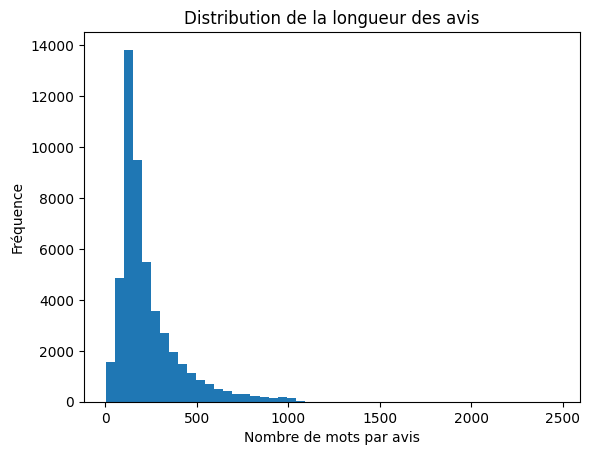

In [8]:
data['nb_mots'] = data['review'].apply(lambda x: len(x.split()))


plt.hist(data['nb_mots'], bins=50)
plt.xlabel("Nombre de mots par avis")
plt.ylabel("Fréquence")
plt.title("Distribution de la longueur des avis")
plt.show()

#Nettoyage du texte



In [9]:
import re

def clean_text(text):

    text = re.sub(r'<.*?>', ' ', text)


    text = re.sub(r'[^a-zA-Z\s]', '', text)


    text = text.lower()


    text = re.sub(r'\s+', ' ', text).strip()

    return text

data['review_clean'] = data['review'].apply(clean_text)


print("AVANT :", data['review'][0][:200])
print("APRÈS :", data['review_clean'][0][:200])

AVANT : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
APRÈS : one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its bru


#Enlèvement du stopwords

In [10]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):

    mots = text.split()
    mots_utiles = [mot for mot in mots if mot not in stop_words]
    return ' '.join(mots_utiles)

data['review_clean'] = data['review_clean'].apply(remove_stopwords)

print(data['review_clean'][0][:200])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


one reviewers mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls 


#WordCloud

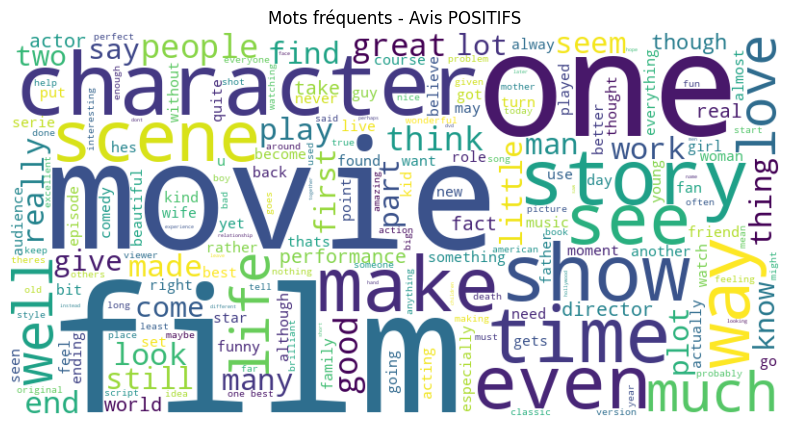

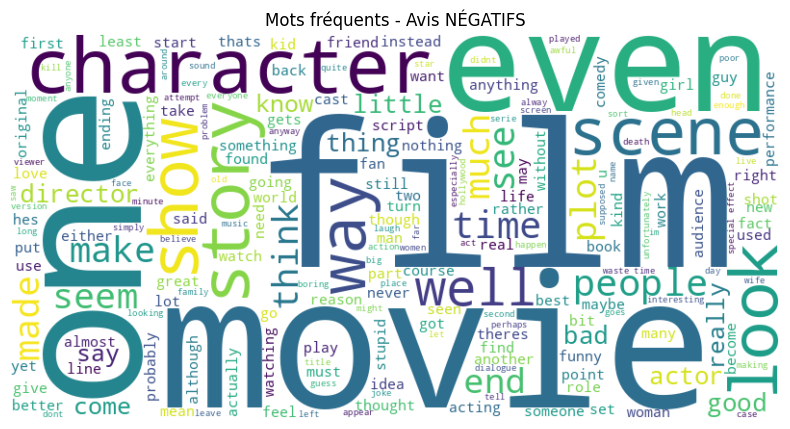

In [11]:
from wordcloud import WordCloud

texte_positif = ' '.join(data[data['sentiment'] == 'positive']['review_clean'])
texte_negatif = ' '.join(data[data['sentiment'] == 'negative']['review_clean'])

wc_positif = WordCloud(width=800, height=400, background_color='white').generate(texte_positif)
plt.figure(figsize=(10,5))
plt.imshow(wc_positif, interpolation='bilinear')
plt.axis('off')
plt.title("Mots fréquents - Avis POSITIFS")
plt.show()

wc_negatif = WordCloud(width=800, height=400, background_color='white').generate(texte_negatif)
plt.figure(figsize=(10,5))
plt.imshow(wc_negatif, interpolation='bilinear')
plt.axis('off')
plt.title("Mots fréquents - Avis NÉGATIFS")
plt.show()

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data['review_clean'])

print("Forme de X :", X.shape)


Forme de X : (50000, 5000)


In [13]:
y = data ['sentiment'].map({'positive':1, 'negative':0})
y.head()

,sentiment
0,1
1,1
2,1
3,0
4,1


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Taille entraînement :{X_train.shape}")
print(f"Taille test : {X_test.shape}")

Taille entraînement :(40000, 5000)
Taille test : (10000, 5000)


#Entrainer le premier modèle NaiveBayes

In [15]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

#Evaluer le modèle

Accuracy : 0.8515

Rapport détaillé :
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



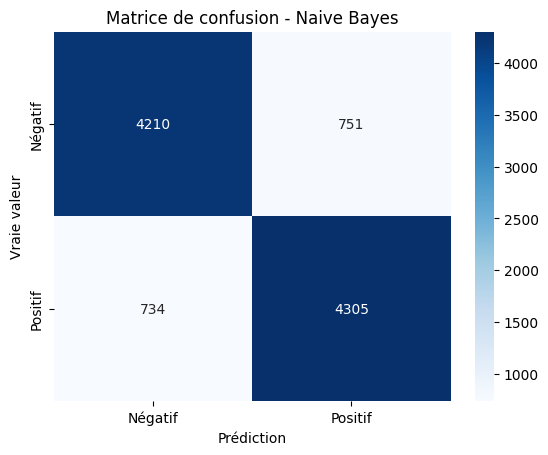

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("\nRapport détaillé :\n", classification_report(y_test, y_pred_nb))


import seaborn as sns
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Négatif', 'Positif'],
            yticklabels=['Négatif', 'Positif'])
plt.xlabel("Prédiction")
plt.ylabel("Vraie valeur")
plt.title("Matrice de confusion - Naive Bayes")
plt.show()

#Deuxième modèle

In [17]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Accuracy Régression Logistique :", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy Régression Logistique : 0.8892
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



#Trosième modèle

In [18]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

print("Accuracy SVM :", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy SVM : 0.8805
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [19]:
def predire_sentiment(texte, model, vectorizer):

    texte_nettoye = clean_text(texte)
    texte_nettoye = remove_stopwords(texte_nettoye)


    texte_vectorise = vectorizer.transform([texte_nettoye])


    prediction = model.predict(texte_vectorise)[0]
    proba = model.predict_proba(texte_vectorise)[0]

    resultat = "POSITIF" if prediction == 1 else "NÉGATIF"
    confiance = max(proba) * 100

    return f"{resultat} (confiance : {confiance:.1f}%)"

# Teste avec tes propres phrases !
print(predire_sentiment("This movie was absolutely amazing, I loved every minute!", model_lr, vectorizer))
print(predire_sentiment("Terrible film, a complete waste of time.", model_lr, vectorizer))

POSITIF (confiance : 95.8%)
NÉGATIF (confiance : 100.0%)


In [20]:
print(predire_sentiment("this teacher is very good", model_nb, vectorizer))

POSITIF (confiance : 52.3%)


#Sauvegardons le modèle

In [21]:
import joblib

# On sauvegarde le modèle ET le vectorizer (les deux sont nécessaires pour prédire plus tard)
joblib.dump(model_lr, 'modele_sentiment.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')



['vectorizer.pkl']

In [22]:
from google.colab import files

files.download('modele_sentiment.pkl')
files.download('vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
pip install transformers torch

In [24]:
from transformers import pipeline


sentiment_pipeline = pipeline("sentiment-analysis")

resultat = sentiment_pipeline("This movie was absolutely amazing!")
print(resultat)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998781681060791}]


In [25]:
# Étape 1 : installer streamlit et localtunnel
!pip install streamlit -q
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 64.7 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 7s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [28]:
%%writefile app.py

import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords

# Télécharger les stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Charger le modèle et le vectorizer
model = joblib.load("modele_sentiment.pkl")
vectorizer = joblib.load("vectorizer.pkl")


# -----------------------------
# NETTOYAGE DU TEXTE
# -----------------------------

def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def remove_stopwords(text):
    mots = text.split()
    mots_utiles = [
        mot for mot in mots
        if mot not in stop_words
    ]
    return " ".join(mots_utiles)


# -----------------------------
# PRÉDICTION
# -----------------------------

def predire_sentiment(texte, model, vectorizer):

    texte_nettoye = clean_text(texte)
    texte_nettoye = remove_stopwords(texte_nettoye)

    texte_vectorise = vectorizer.transform([texte_nettoye])

    prediction = model.predict(texte_vectorise)[0]

    proba = model.predict_proba(texte_vectorise)[0]

    resultat = "POSITIF" if prediction == 1 else "NÉGATIF"

    confiance = max(proba) * 100

    return f"{resultat} (confiance : {confiance:.1f}%)"


# -----------------------------
# INTERFACE STREAMLIT
# -----------------------------

st.title("🎬 Analyse de sentiment - Avis de films")

texte_utilisateur = st.text_area(
    "Écris un avis de film :"
)

if st.button("Analyser"):

    if texte_utilisateur.strip():

        resultat = predire_sentiment(
            texte_utilisateur,
            model,
            vectorizer
        )

        st.write(resultat)

    else:
        st.warning("Veuillez écrire un avis de film.")

Overwriting app.py


In [29]:
!pip install -q streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
changed 22 packages in 3s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [ ]:
# Étape 3 : lancer streamlit en arrière-plan + créer le tunnel
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://rotten-sites-lead.loca.lt
